# Pipeline Test
If you intend to run the code in this repository, make sure this notebook runs on your computer as a sanity check. 
Different pitfalls have been tested here (e. g. wrong installation of NumPy version, issues with MNE library, ...).

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [2]:
import numpy as np
import scipy
import mne
print(f"Numpy: {np.__version__}") # Should be 1.26.x
print(f"SciPy: {scipy.__version__}") # Should be 1.11+
print("Kernel started successfully!")

Numpy: 1.26.4
SciPy: 1.12.0
Kernel started successfully!


In [3]:
%load_ext autoreload
%autoreload 2
import torch
from preprocess import load_subject_data

print("Testing processing for subject 1")
X_single, y_single = load_subject_data(subject_id=1)

print(f"Success! X shape: {X_single.shape}, y shape: {y_single.shape}")

Testing processing for subject 1
Checkpoint 1: Loading EDF files
Extracting EDF parameters from /Users/anton/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/anton/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/anton/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Checkpoint 2: Annotations and Montage
Used Annotations descriptions: ['T0', 'T1', 'T2']
Checkpoint 3: Filtering
Filtering raw data in 3 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
-------------------

In [4]:
# Save the single subject as the "processed" data for testing
np.save('eeg_X_preprocessed.npy', X_single)
np.save('eeg_y_preprocessed.npy', y_single)
print("Test .npy files created!")

Test .npy files created!


In [5]:
from datamodule import create_dataloaders

# Use a tiny batch size for testing
batch_size = 2
train_loader, val_loader, test_loader = create_dataloaders(batch_size=batch_size)

print("Dataloaders created successfully!")

Subjects, train: 31, val: 5, test: 9
Dataloaders created successfully!


Subjects performed each 15 trials for a task and in this case the experimental runs 4, 8 and 12 were selected -> 3 x 15 = 45
With a 70/10/20 split that gives 31 training recordings, 5 for validation and 9 for testing.

In [6]:
# Grab one batch from the train_loader
batch_X, batch_y = next(iter(train_loader))

print(f"Batch X shape: {batch_X.shape}") # Expected: (batch_size, 64, samples)
print(f"Batch y shape: {batch_y.shape}") # Expected: (batch_size,)
print(f"Batch X dtype: {batch_X.dtype}") # Expected: torch.float32
print(f"Batch y dtype: {batch_y.dtype}") # Expected: torch.float32

# Simple check: does it have values?
print(f"X mean: {batch_X.mean():.4f}")

Batch X shape: torch.Size([2, 64, 481])
Batch y shape: torch.Size([2])
Batch X dtype: torch.float32
Batch y dtype: torch.float32
X mean: 0.0213


## Shape Explanations
* Batch X shape: 2 numbers of trials in batch, 64 channels/electrodes and 481 samples/time-points in each trial
* Samples: The individual time-points (bins) recorded at the sampling rate of 160 Hz (calculated: 3s x 160 Hz = 1 = 480 samples)
* X mean: should be close to 0 to show that the z-score normalization is working as it should :)

# Testing the Main Architecture
## 1. Overfitting Artificial Data
To check the learning process small input data matching the original data shape is created and then passed onto the main CNN-Classifier (using a reduced embedding dimension and fewer heads for the MHA to save computation ressources), which is trained for 10 epochs to verify whether the data pipeline fundamentally works.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from model import EEGClassifier, BaselineCNN
from datamodule import create_dataloaders
from train import train, plot_metrics
from dataset import PreprocessedDataset
from evaluate import evaluate, get_predictions, visualize_predictions


device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [8]:
# Dummy data - 10 trials, 64 channels, 481 samples
X_tiny = np.random.randn(10, 64, 481).astype(np.float32)
y_tiny = np.random.randint(0, 2, 10).astype(np.float32)

np.save('eeg_X_preprocessed.npy', X_tiny)
np.save('eeg_y_preprocessed.npy', y_tiny)

In [9]:
batch_size = 2
train_loader, val_loader, test_loader = create_dataloaders(batch_size=batch_size)

model_test_main = EEGClassifier(
    n_channels=64, 
    emb_dim=32, 
    n_heads=2, 
    dropout=0.1, 
    fs=160
)

optimizer_test_main = optim.Adam(model_test_main.parameters(), lr=0.001, weight_decay=1e-4)

Subjects, train: 7, val: 1, test: 2


Epoch 1/10 | Train Loss 0.4699 | Val Kappa: 0.0000
Epoch 2/10 | Train Loss 0.4683 | Val Kappa: 0.0000
Epoch 3/10 | Train Loss 0.4861 | Val Kappa: 0.0000
Epoch 4/10 | Train Loss 0.3461 | Val Kappa: 0.0000
Epoch 5/10 | Train Loss 0.2826 | Val Kappa: 0.0000
Epoch 6/10 | Train Loss 0.3270 | Val Kappa: 0.0000
Epoch 7/10 | Train Loss 0.1726 | Val Kappa: 0.0000
Epoch 8/10 | Train Loss 0.2696 | Val Kappa: 0.0000
Epoch 9/10 | Train Loss 0.1747 | Val Kappa: 0.0000
Epoch 10/10 | Train Loss 0.1339 | Val Kappa: 0.0000
Dry run completed with success.


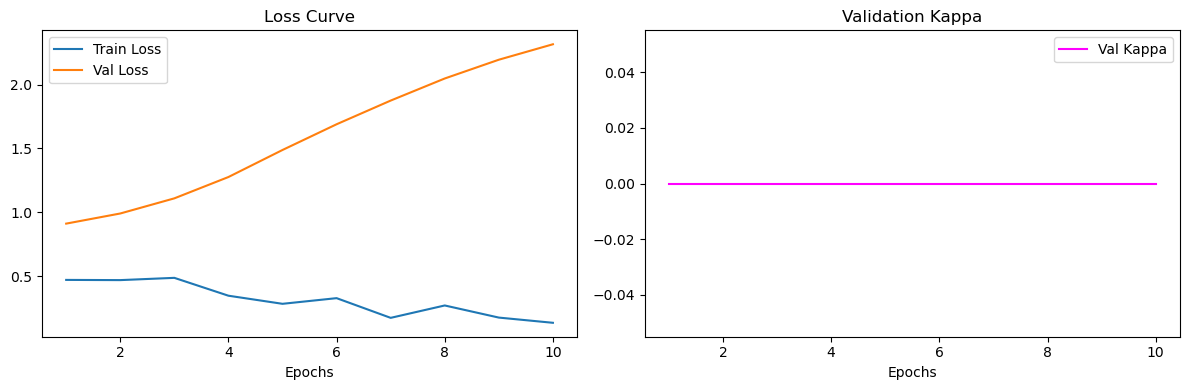

In [10]:
n_epochs_test = 10

trained_model, history = train(
    model=model_test_main,
    n_epochs=n_epochs_test,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_test_main,
    device=device
)

print('Dry run completed with success.')
plot_metrics(history)

Epoch 1/10 | Train Loss 0.7028 | Val Kappa: 0.0000
Epoch 2/10 | Train Loss 0.6892 | Val Kappa: 0.0000
Epoch 3/10 | Train Loss 0.6699 | Val Kappa: 0.0000
Epoch 4/10 | Train Loss 0.6417 | Val Kappa: 0.0000
Epoch 5/10 | Train Loss 0.6033 | Val Kappa: 0.0000
Epoch 6/10 | Train Loss 0.5582 | Val Kappa: 0.0000
Epoch 7/10 | Train Loss 0.5217 | Val Kappa: 0.0000
Epoch 8/10 | Train Loss 0.4767 | Val Kappa: 0.0000
Epoch 9/10 | Train Loss 0.4470 | Val Kappa: 0.0000
Epoch 10/10 | Train Loss 0.4240 | Val Kappa: 0.0000


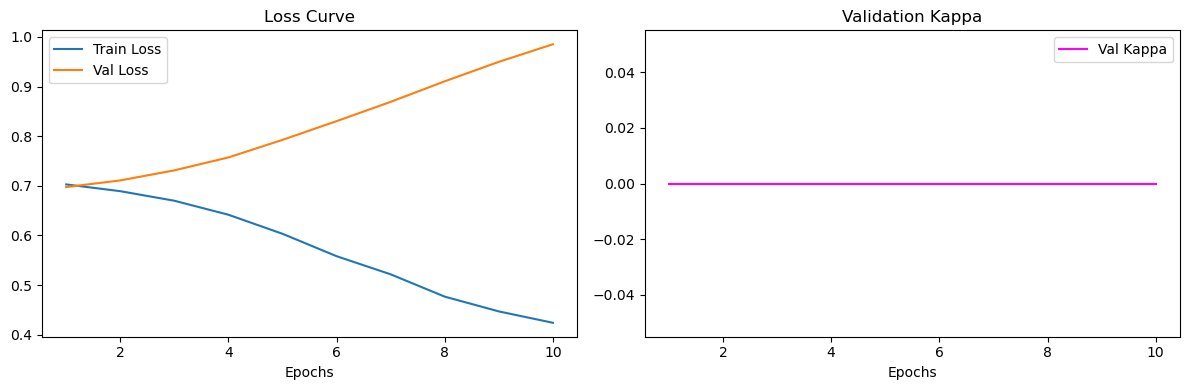

In [11]:
# Test Baseline Model
model_baseline_test = BaselineCNN()
optimizer_baseline_test = optim.Adam(model_baseline_test.parameters(), lr=0.001, weight_decay=1e-4)

trained_baseline_test, history_baseline = train(
    model=model_baseline_test,
    n_epochs=n_epochs_test,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_baseline_test,
    device=device
)

plot_metrics(history_baseline)

## 2. Testing Models on Small Original Data

In [12]:
print("Preprocessing subjects 1 and 2...")
X1, y1 = load_subject_data(subject_id=1)
X2, y2 = load_subject_data(subject_id=2)

X = np.concatenate([X1, X2], axis=0)
y = np.concatenate([y1, y2], axis=0)

dataset = PreprocessedDataset(X, y)

np.save('eeg_X_preprocessed.npy', X)
np.save('eeg_y_preprocessed.npy', y)

print(f"Success! Tiny dataset created. X shape: {X.shape}")

Preprocessing subjects 1 and 2...
Checkpoint 1: Loading EDF files
Extracting EDF parameters from /Users/anton/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/anton/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/anton/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Checkpoint 2: Annotations and Montage
Used Annotations descriptions: ['T0', 'T1', 'T2']
Checkpoint 3: Filtering
Filtering raw data in 3 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
------------------

In [13]:
batch_size = 2
train_loader, val_loader, test_loader = create_dataloaders(batch_size=batch_size)

model_test_main = EEGClassifier(
    n_channels=64, 
    emb_dim=32, 
    n_heads=2, 
    dropout=0.1, 
    fs=160
)

optimizer_test_main = optim.Adam(model_test_main.parameters(), lr=0.001, weight_decay=1e-4)

Subjects, train: 61, val: 9, test: 18


Epoch 1/20 | Train Loss 0.7145 | Val Kappa: 0.0526
Epoch 2/20 | Train Loss 0.6936 | Val Kappa: 0.0000
Epoch 3/20 | Train Loss 0.6797 | Val Kappa: 0.1818
Epoch 4/20 | Train Loss 0.6938 | Val Kappa: 0.0000
Epoch 5/20 | Train Loss 0.6141 | Val Kappa: 0.7805
Epoch 6/20 | Train Loss 0.4123 | Val Kappa: 0.7805
Epoch 7/20 | Train Loss 0.2269 | Val Kappa: 0.7805
Epoch 8/20 | Train Loss 0.1479 | Val Kappa: 0.7805
Epoch 9/20 | Train Loss 0.0773 | Val Kappa: 0.5714
Epoch 10/20 | Train Loss 0.0933 | Val Kappa: 0.7805
Epoch 11/20 | Train Loss 0.0296 | Val Kappa: 0.7805
Epoch 12/20 | Train Loss 0.0211 | Val Kappa: 0.7805
Epoch 13/20 | Train Loss 0.0214 | Val Kappa: 0.7805
Epoch 14/20 | Train Loss 0.0199 | Val Kappa: 0.7805
Epoch 15/20 | Train Loss 0.0180 | Val Kappa: 0.7805
Epoch 16/20 | Train Loss 0.0075 | Val Kappa: 0.7805
Epoch 17/20 | Train Loss 0.0109 | Val Kappa: 0.7805
Epoch 18/20 | Train Loss 0.0077 | Val Kappa: 0.7805
Epoch 19/20 | Train Loss 0.0064 | Val Kappa: 0.7805
Epoch 20/20 | Train L

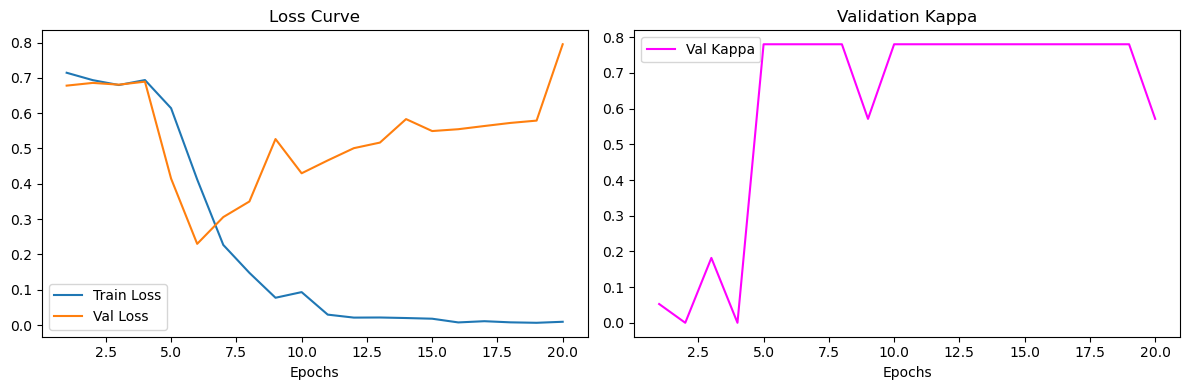

In [14]:
n_epochs_test = 20

trained_model, history = train(
    model=model_test_main,
    n_epochs=n_epochs_test,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_test_main,
    device=device
)

print('Dry run completed with success.')
plot_metrics(history)

Prediction Distribution:
{0: 13, 1: 5}
Cohen's Kappa: 0.3933


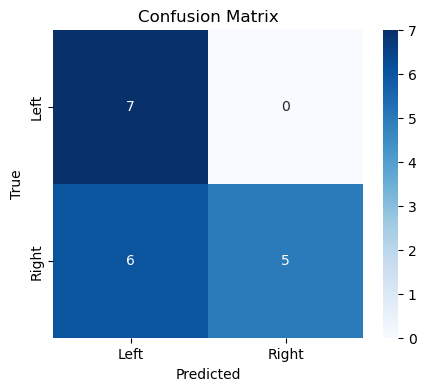

In [15]:
criterion = nn.BCEWithLogitsLoss()

evaluate(trained_model, test_loader, criterion, device)
y_true, y_pred = get_predictions(trained_model, test_loader, device)
visualize_predictions(y_true, y_pred)